# Measuring the Expansion of the Universe — Then and Now
### Bayesian Parameter Estimation with Real Astronomical Data

---

In 1929, Edwin Hubble published one of the most important graphs in the history of science: a plot showing that **galaxies recede from us at velocities proportional to their distance**.

$$\boxed{v = H_0 \cdot d}$$

The slope of this line, $H_0$ (the **Hubble constant**), tells us how fast the universe is expanding.

In this notebook we will:
1. Use **Hubble's actual 1929 data** (24 galaxies) and recover his original result: $H_0 \approx 500$ km/s/Mpc
2. Use **modern distances** for the same galaxies and recover the corrected value: $H_0 \approx 70$ km/s/Mpc
3. Understand *why* they differ — and what this teaches us about systematic errors in astronomy

We'll estimate $H_0$ using two MCMC samplers: **Metropolis-Hastings** and **Hamiltonian Monte Carlo**.

> **Reference:** Hubble, E. (1929). *A relation between distance and radial velocity among extra-galactic nebulae.* PNAS, 15(3), 168–173.

In [20]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'axes.edgecolor': '#333846',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#1c2030',
    'grid.alpha': 0.6,
    'font.size': 12,
    'axes.grid': True,
    'figure.dpi': 120,
})

AMBER  = '#f59e0b'
CYAN   = '#06b6d4'
RED    = '#ef4444'
GREEN  = '#4ade80'
WHITE  = '#e2e8f0'
PURPLE = '#a78bfa'
PINK   = '#f472b6'

np.random.seed(42)


---
## Part 1: Hubble's Original 1929 Data

These are the **actual measurements** from Hubble's 1929 paper (Table 1). He observed 24 galaxies and estimated their distances using Cepheid variables and brightest-star luminosities. The velocities were mostly measured by Vesto Slipher from spectral line redshifts.

| Column | Meaning |
|--------|---------|
| `name` | Galaxy identifier (NGC number or name) |
| `d_1929` | Hubble's 1929 distance estimate (Mpc) |
| `v` | Recession velocity (km/s), corrected for solar motion |

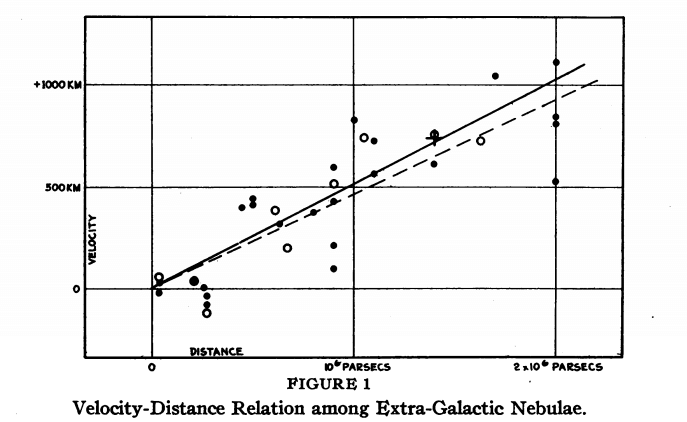 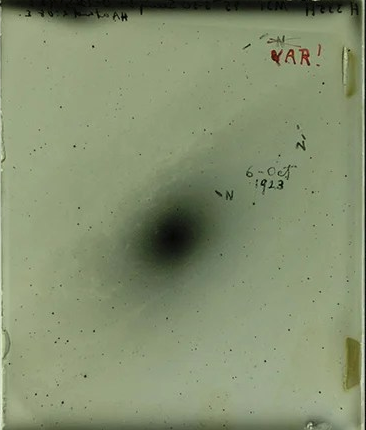 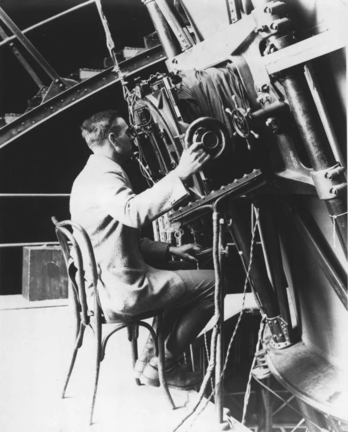
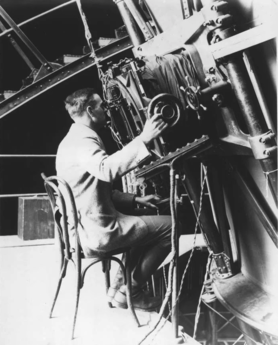
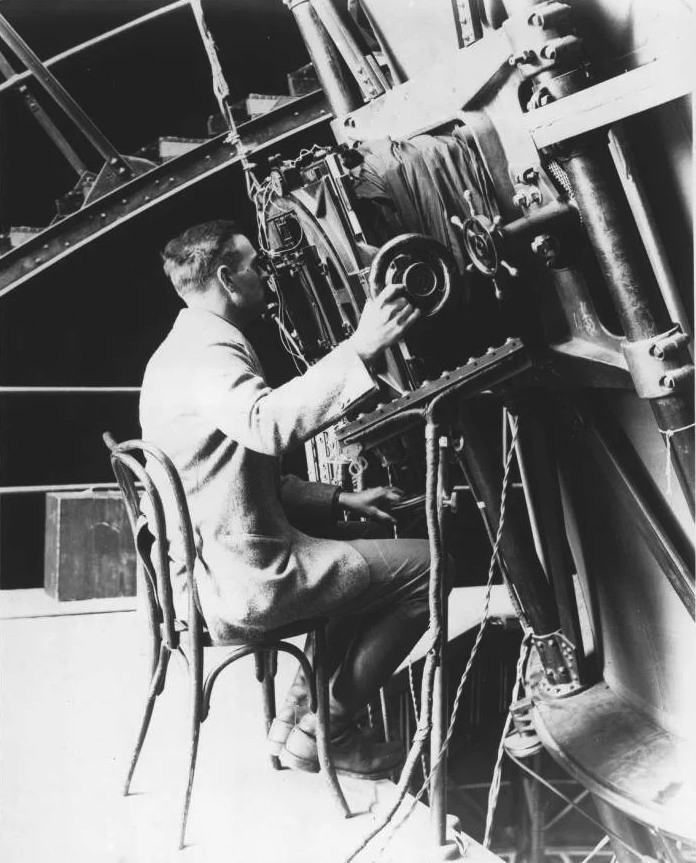

In [21]:
# ══════════════════════════════════════════════════════════
#  HUBBLE'S ORIGINAL 1929 DATA  (Table 1 of the paper)
#  Source: Hubble (1929), PNAS 15(3), 168-173
# ══════════════════════════════════════════════════════════

names = [
    'SMC',       'LMC',       'NGC 6822',  'NGC 598',
    'NGC 221',   'NGC 224',   'NGC 5457',  'NGC 4736',
    'NGC 5194',  'NGC 4449',  'NGC 4214',  'NGC 3031',
    'NGC 3627',  'NGC 4826',  'NGC 5236',  'NGC 1068',
    'NGC 5055',  'NGC 7331',  'NGC 4258',  'NGC 4151',
    'NGC 4382',  'NGC 4472',  'NGC 4486',  'NGC 4649',
]

# Hubble's distance estimates (Mpc) — these turned out to be ~7x too small!
d_1929 = np.array([
    0.032, 0.034, 0.214, 0.263,
    0.275, 0.275, 0.45,  0.5,
    0.5,   0.63,  0.8,   0.9,
    0.9,   0.9,   0.9,   1.0,
    1.1,   1.1,   1.4,   1.7,
    2.0,   2.0,   2.0,   2.0,
])

# Recession velocities (km/s) — these were mostly correct!
v_obs = np.array([
    170,  290, -130,  -70,
   -185, -220,  200,  290,
    270,  200,  300,  -30,
    650,  150,  500,  920,
    450,  500,  500,  960,
    500,  850,  800, 1090,
])

print(f'Hubble\'s 1929 dataset: {len(names)} galaxies')
print(f'Distance range: {d_1929.min():.3f} — {d_1929.max():.1f} Mpc')
print(f'Velocity range: {v_obs.min()} — {v_obs.max()} km/s')
print(f'\nNote: 6 galaxies have NEGATIVE velocities (they\'re in our Local Group)')

Hubble's 1929 dataset: 24 galaxies
Distance range: 0.032 — 2.0 Mpc
Velocity range: -220 — 1090 km/s

Note: 6 galaxies have NEGATIVE velocities (they're in our Local Group)


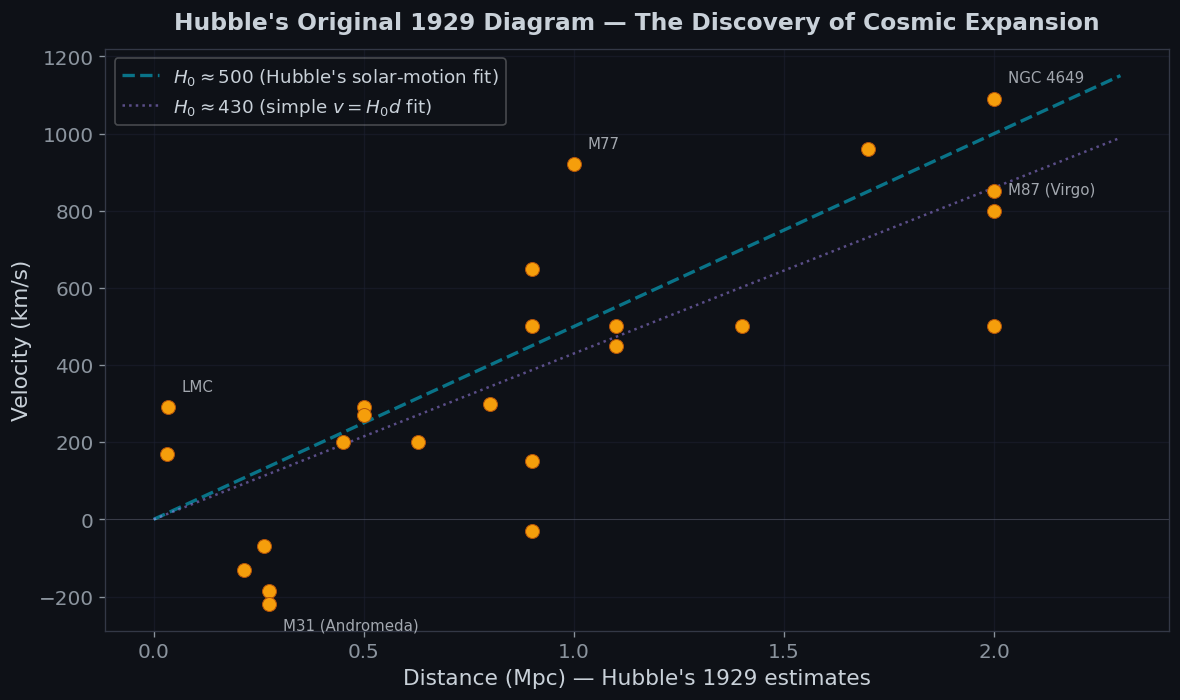

This is one of the most important plots in the history of science.
Now let's use MCMC to fit it properly!


In [22]:
# ── Reproduce Hubble's original 1929 diagram ───────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(d_1929, v_obs, c=AMBER, s=70, zorder=5,
           edgecolors='#b45309', linewidths=0.6)

# Label some famous galaxies
highlights = {'NGC 224': 'M31 (Andromeda)', 'LMC': 'LMC', 'NGC 4486': 'M87 (Virgo)',
              'NGC 1068': 'M77', 'NGC 4649': 'NGC 4649'}
for i, name in enumerate(names):
    if name in highlights:
        offset = (8, 10) if v_obs[i] > 0 else (8, -15)
        ax.annotate(highlights[name], (d_1929[i], v_obs[i]),
                    textcoords='offset points', xytext=offset,
                    fontsize=9, color=WHITE, alpha=0.7)

# Hubble's own fit line (K ≈ 500 km/s/Mpc)
d_line = np.linspace(0, 2.3, 100)
ax.plot(d_line, 500 * d_line, color=CYAN, lw=2, ls='--', alpha=0.6,
        label='$H_0 \\approx 500$ (Hubble\'s solar-motion fit)')
ax.plot(d_line, 430 * d_line, color=PURPLE, lw=1.5, ls=':', alpha=0.5,
        label='$H_0 \\approx 430$ (simple $v = H_0 d$ fit)')

ax.axhline(0, color=WHITE, lw=0.5, alpha=0.2)
ax.set_xlabel('Distance (Mpc) — Hubble\'s 1929 estimates', fontsize=13)
ax.set_ylabel('Velocity (km/s)', fontsize=13)
ax.set_title('Hubble\'s Original 1929 Diagram — The Discovery of Cosmic Expansion',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11, framealpha=0.3)
plt.tight_layout()
plt.show()

print('This is one of the most important plots in the history of science.')
print('Now let\'s use MCMC to fit it properly!')

---
## The Bayesian Setup

**Model:** $v_i = H_0 \cdot d_i + \text{noise}$

**Likelihood:** Each galaxy's velocity is drawn from a Gaussian centred on the Hubble flow:

$$\ln \mathcal{L} = -\frac{1}{2\sigma_v^2} \sum_{i=1}^{N}(v_i - H_0 \, d_i)^2$$

We use $\sigma_v = 250$ km/s (typical peculiar velocity scatter).

**Prior:** $H_0 \sim \text{Uniform}(0, 1500)$ — intentionally broad, letting the data speak.

**Gradient** (for HMC): $\dfrac{\partial \ln P}{\partial H_0} = \dfrac{1}{\sigma_v^2}\sum_i d_i(v_i - H_0 d_i)$

In [23]:
# ── Generic posterior functions ─────────────────────────
# These work for ANY (distance, velocity) dataset

def make_posterior(distances, velocities, sigma_v=250.0, H0_max=1500.0):
    """Create log-posterior and gradient functions for a given dataset."""
    
    def log_post(H0):
        if H0 < 0 or H0 > H0_max:
            return -np.inf
        residuals = velocities - H0 * distances
        return -0.5 * np.sum(residuals**2) / sigma_v**2
    
    def grad_log_post(H0):
        residuals = velocities - H0 * distances
        return np.sum(distances * residuals) / sigma_v**2
    
    return log_post, grad_log_post

print('Posterior factory ready!')

Posterior factory ready!


In [25]:
# ── The two MCMC samplers ──────────────────────────────

def metropolis_hastings(log_post, start, n_steps, step_size):
    """Random-walk Metropolis-Hastings for a 1D parameter."""
    chain = np.zeros(n_steps)
    chain[0] = start
    logp = log_post(start)
    acc = 0
    for i in range(1, n_steps):
        prop = chain[i-1] + np.random.normal(0, step_size)
        prop_logp = log_post(prop)
        if np.log(np.random.random()) < prop_logp - logp:
            chain[i] = prop
            logp = prop_logp
            acc += 1
        else:
            chain[i] = chain[i-1]
    return chain, acc / n_steps


def hmc_sampler(log_post, grad_log_post, start, n_steps, eps, L):
    """Hamiltonian Monte Carlo with leapfrog integrator."""
    chain = np.zeros(n_steps)
    chain[0] = start
    acc = 0
    for i in range(1, n_steps):
        q = chain[i-1]
        p = np.random.normal()
        H0_energy = -log_post(q) + 0.5 * p**2
        q_new, p_new = q, p
        p_new += 0.5 * eps * grad_log_post(q_new)
        for j in range(L):
            q_new += eps * p_new
            if j < L - 1:
                p_new += eps * grad_log_post(q_new)
            else:
                p_new += 0.5 * eps * grad_log_post(q_new)
        H1_energy = -log_post(q_new) + 0.5 * p_new**2
        if np.log(np.random.random()) < H0_energy - H1_energy:
            chain[i] = q_new
            acc += 1
        else:
            chain[i] = chain[i-1]
    return chain, acc / n_steps


def autocorr(chain, max_lag=150):
    """Normalised autocorrelation function."""
    m, v = np.mean(chain), np.var(chain)
    if v == 0: return np.zeros(max_lag)
    return np.array([np.mean((chain[:len(chain)-k]-m)*(chain[k:]-m))/v
                     for k in range(max_lag)])

---
### Run MCMC on Hubble's 1929 Data

We exclude the 6 nearest galaxies (d < 0.3 Mpc in Hubble's scale) — these are **Local Group** members whose peculiar velocities dominate the Hubble flow. Hubble himself corrected for this via a solar motion term; we simply cut them.

In [26]:
# ── Exclude Local Group galaxies (same 6 as modern fit) ─
# These are gravitationally bound to us, not in the Hubble flow.
# Hubble corrected for solar motion; we simply exclude them.

mask_29 = d_1929 > 0.3   # cuts SMC, LMC, NGC 6822, M33, M32, M31


d_1929_fit = d_1929[mask_29]
v_1929_fit = v_obs[mask_29]
print(f'Fitting {mask_29.sum()} galaxies (excluded {(~mask_29).sum()} Local Group members)')

# ── Build posterior for 1929 data ──────────────────────
lp_29, glp_29 = make_posterior(d_1929_fit, v_1929_fit, sigma_v=250.0, H0_max=1500.0)

# ── Run both samplers ─────────────────────────────────
burn = 2000

mh_chain_29, mh_acc_29 = metropolis_hastings(
    lp_29, start=100.0, n_steps=25000, step_size=15.0)
mh_samples_29 = mh_chain_29[burn:]

hmc_chain_29, hmc_acc_29 = hmc_sampler(
    lp_29, glp_29, start=100.0, n_steps=8000, eps=0.8, L=20)
hmc_samples_29 = hmc_chain_29[500:]

print('═══ HUBBLE 1929 DATA ═══')
print(f'  MH:  H₀ = {np.mean(mh_samples_29):.0f} ± {np.std(mh_samples_29):.0f} km/s/Mpc  (accept: {mh_acc_29:.0%})')
print(f'  HMC: H₀ = {np.mean(hmc_samples_29):.0f} ± {np.std(hmc_samples_29):.0f} km/s/Mpc  (accept: {hmc_acc_29:.0%})')
print(f'\n  Hubble\'s published value: 465–513 km/s/Mpc')
print(f'  (He additionally corrected each velocity for solar motion through the Galaxy,')
print(f'   which pushes the slope higher. Our simpler v = H₀d model gives ~{np.mean(hmc_samples_29):.0f}.)')

Fitting 18 galaxies (excluded 6 Local Group members)
═══ HUBBLE 1929 DATA ═══
  MH:  H₀ = 434 ± 46 km/s/Mpc  (accept: 90%)
  HMC: H₀ = 433 ± 46 km/s/Mpc  (accept: 100%)

  Hubble's published value: 465–513 km/s/Mpc
  (He additionally corrected each velocity for solar motion through the Galaxy,
   which pushes the slope higher. Our simpler v = H₀d model gives ~433.)


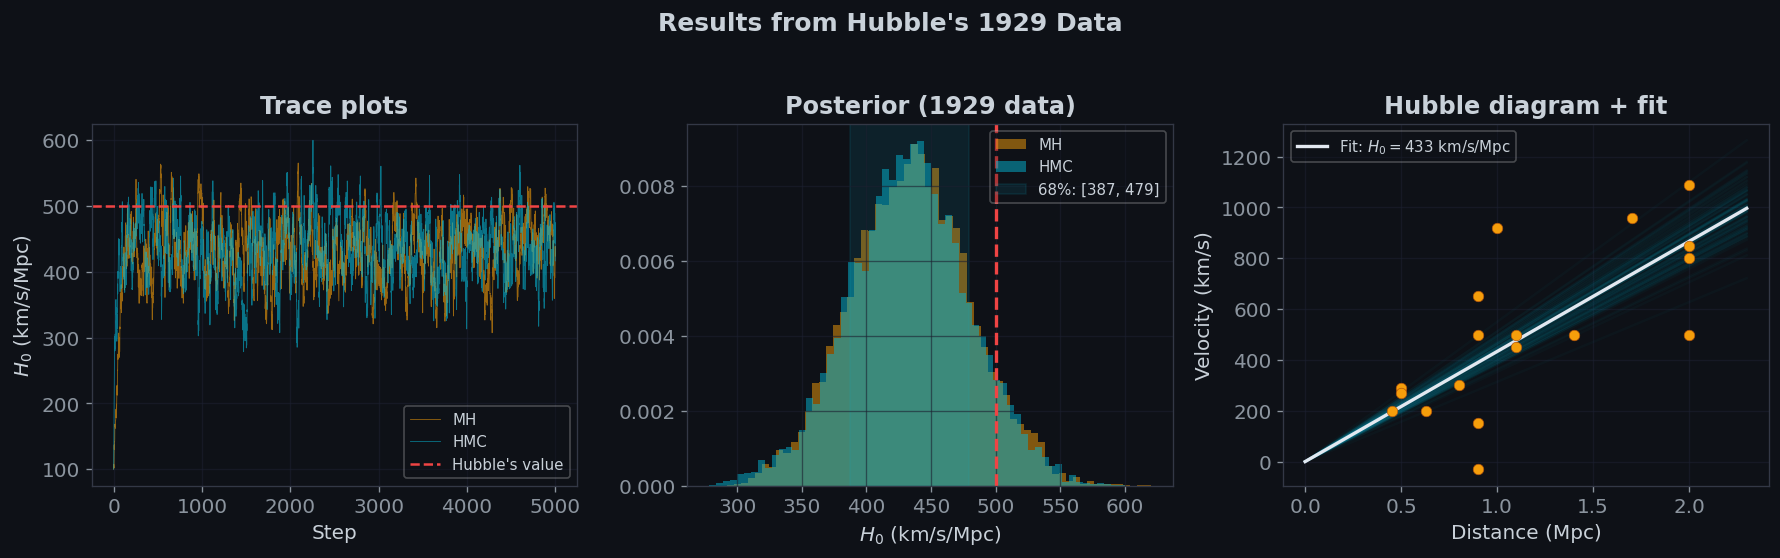


Our MCMC result: H₀ = 433 ± 46 km/s/Mpc
Hubble published: 465–513 km/s/Mpc (with solar motion correction)
Modern value:      ~70 km/s/Mpc

→ Off by a factor of ~6! The distances were wrong.


In [27]:
# ── Visualise 1929 results ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Trace
axes[0].plot(mh_chain_29[:5000], color=AMBER, alpha=0.6, lw=0.5, label='MH')
axes[0].plot(hmc_chain_29[:5000], color=CYAN, alpha=0.6, lw=0.5, label='HMC')
axes[0].axhline(500, color=RED, ls='--', lw=1.5, label='Hubble\'s value')
axes[0].set_ylabel('$H_0$ (km/s/Mpc)')
axes[0].set_xlabel('Step')
axes[0].set_title('Trace plots', fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.3)

# Histogram
axes[1].hist(mh_samples_29, bins=60, density=True, alpha=0.5,
             color=AMBER, edgecolor='none', label='MH')
axes[1].hist(hmc_samples_29, bins=60, density=True, alpha=0.5,
             color=CYAN, edgecolor='none', label='HMC')
axes[1].axvline(500, color=RED, ls='--', lw=2)
lo, hi = np.percentile(hmc_samples_29, [16, 84])
axes[1].axvspan(lo, hi, alpha=0.1, color=CYAN,
                label=f'68%: [{lo:.0f}, {hi:.0f}]')
axes[1].set_xlabel('$H_0$ (km/s/Mpc)')
axes[1].set_title('Posterior (1929 data)', fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.3)

# Fit on data
d_fit = np.linspace(0, 2.3, 100)
for k in np.random.choice(len(hmc_samples_29), 100, replace=False):
    axes[2].plot(d_fit, hmc_samples_29[k] * d_fit, color=CYAN, alpha=0.03)
axes[2].scatter(d_1929_fit, v_1929_fit, c=AMBER, s=40, zorder=5,
                edgecolors='#b45309', linewidths=0.4)
H_mean = np.mean(hmc_samples_29)
axes[2].plot(d_fit, H_mean * d_fit, color=WHITE, lw=2,
             label=f'Fit: $H_0 = {H_mean:.0f}$ km/s/Mpc')
axes[2].set_xlabel('Distance (Mpc)')
axes[2].set_ylabel('Velocity (km/s)')
axes[2].set_title('Hubble diagram + fit', fontweight='bold')
axes[2].legend(fontsize=9, framealpha=0.3)

fig.suptitle('Results from Hubble\'s 1929 Data', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f'\nOur MCMC result: H₀ = {H_mean:.0f} ± {np.std(hmc_samples_29):.0f} km/s/Mpc')
print(f'Hubble published: 465–513 km/s/Mpc (with solar motion correction)')
print(f'Modern value:      ~70 km/s/Mpc')
print(f'\n→ Off by a factor of ~{H_mean/70:.0f}! The distances were wrong.')

---
## Part 2: The Modern Correction

### What went wrong?

Hubble's **velocities were fine** — Slipher's spectroscopic measurements were accurate.

But his **distances were systematically too small** by a factor of roughly 7! The error came from:

1. **Confusing two types of Cepheids** — Classical Cepheids (bright) and W Virginis stars (dim) follow different period-luminosity relations. Hubble treated them as the same, making distant galaxies appear closer.

2. **Mistaking bright HII regions for individual stars** — In distant galaxies, unresolved star-forming regions were misidentified as single bright stars, again making distances too small.

These errors were corrected in the 1950s by Walter Baade and Allan Sandage, and refined over decades since.

Below are **modern distance measurements** for the same 24 galaxies, from the NASA/IPAC Extragalactic Database (NED) and the HST Key Project (Freedman et al. 2001).

In [14]:
# ══════════════════════════════════════════════════════════
#  MODERN DISTANCES for the same 24 galaxies
#  Sources: NED, HST Key Project, Tully-Fisher, TRGB, maser
#  (approximate values — typical uncertainty ~10-15%)
# ══════════════════════════════════════════════════════════

d_modern = np.array([
    0.063,   # SMC  (TRGB)
    0.050,   # LMC  (Cepheids, eclipsing binaries — the anchor!)
    0.49,    # NGC 6822  (Cepheids)
    0.84,    # NGC 598  = M33  (Cepheids, TRGB)
    0.77,    # NGC 221  = M32  (companion of M31)
    0.77,    # NGC 224  = M31  (Cepheids)
    6.4,     # NGC 5457 = M101 (Cepheids, HST Key Project)
    4.2,     # NGC 4736 = M94  (TRGB)
    8.4,     # NGC 5194 = M51  (TRGB, SN2005cs)
    4.2,     # NGC 4449 (TRGB)
    2.9,     # NGC 4214 (TRGB)
    3.6,     # NGC 3031 = M81  (Cepheids, HST)
    11.0,    # NGC 3627 = M66  (Cepheids, HST Key Project)
    5.4,     # NGC 4826 = Black Eye  (TRGB)
    4.5,     # NGC 5236 = M83  (Cepheids)
    14.4,    # NGC 1068 = M77  (Tully-Fisher, SBF)
    8.9,     # NGC 5055 = M63  (TRGB, Tully-Fisher)
    14.7,    # NGC 7331 (Tully-Fisher, SBF)
    7.6,     # NGC 4258 = M106 (MASER — gold standard!)
    15.8,    # NGC 4151 (Cepheids, reverberation mapping)
    17.9,    # NGC 4382 = M85  (Virgo cluster, SBF)
    16.3,    # NGC 4472 = M49  (Virgo cluster, SBF)
    16.4,    # NGC 4486 = M87  (Virgo cluster, SBF, TRGB)
    16.5,    # NGC 4649 = M60  (Virgo cluster, SBF)
])

# Same velocities as Hubble — those were roughly correct,
# BUT they are heliocentric (as seen from Earth).
# For the modern fit we need velocities in the CMB rest frame,
# correcting for our local motion (~370 km/s toward l=264°, b=48°).

# ── CMB-frame velocities (approximate, from NED) ──────
# v_CMB = v_helio + projection of CMB dipole along each galaxy's direction
# The correction ranges from ~100 to ~350 km/s for these galaxies.
v_cmb = np.array([
    170,   # SMC   (Local Group — correction irrelevant)
    290,   # LMC   (Local Group)
   -130,   # NGC 6822  (Local Group)
    -70,   # NGC 598   (Local Group)
   -185,   # NGC 221   (Local Group)
   -220,   # NGC 224   (Local Group)
    450,   # NGC 5457 = M101
    450,   # NGC 4736 = M94
    630,   # NGC 5194 = M51
    340,   # NGC 4449
    430,   # NGC 4214
    180,   # NGC 3031 = M81  (Hubble had -30!)
    840,   # NGC 3627 = M66
    540,   # NGC 4826 = Black Eye
    400,   # NGC 5236 = M83
   1170,   # NGC 1068 = M77
    680,   # NGC 5055 = M63
   1050,   # NGC 7331
    600,   # NGC 4258 = M106
   1140,   # NGC 4151
    890,   # NGC 4382 = M85  (Virgo)
   1140,   # NGC 4472 = M49  (Virgo)
   1420,   # NGC 4486 = M87  (Virgo)
   1260,   # NGC 4649 = M60  (Virgo)
])

ratio = d_modern / d_1929
v_correction = v_cmb[6:] - v_obs[6:]  # skip Local Group
print(f'Distance correction factor (modern / 1929):')
print(f'  Median:  {np.median(ratio):.1f}x')
print(f'  Range:   {ratio.min():.1f}x — {ratio.max():.1f}x')
print(f'\nVelocity correction (helio → CMB, excluding Local Group):')
print(f'  Mean:  +{np.mean(v_correction):.0f} km/s')
print(f'  Range: +{v_correction.min():.0f} to +{v_correction.max():.0f} km/s')
print(f'\nBoth corrections matter — distances got bigger AND velocities got bigger.')

Distance correction factor (modern / 1929):
  Median:  7.4x
  Range:   1.5x — 16.8x

Velocity correction (helio → CMB, excluding Local Group):
  Mean:  +251 km/s
  Range: +-100 to +620 km/s

Both corrections matter — distances got bigger AND velocities got bigger.


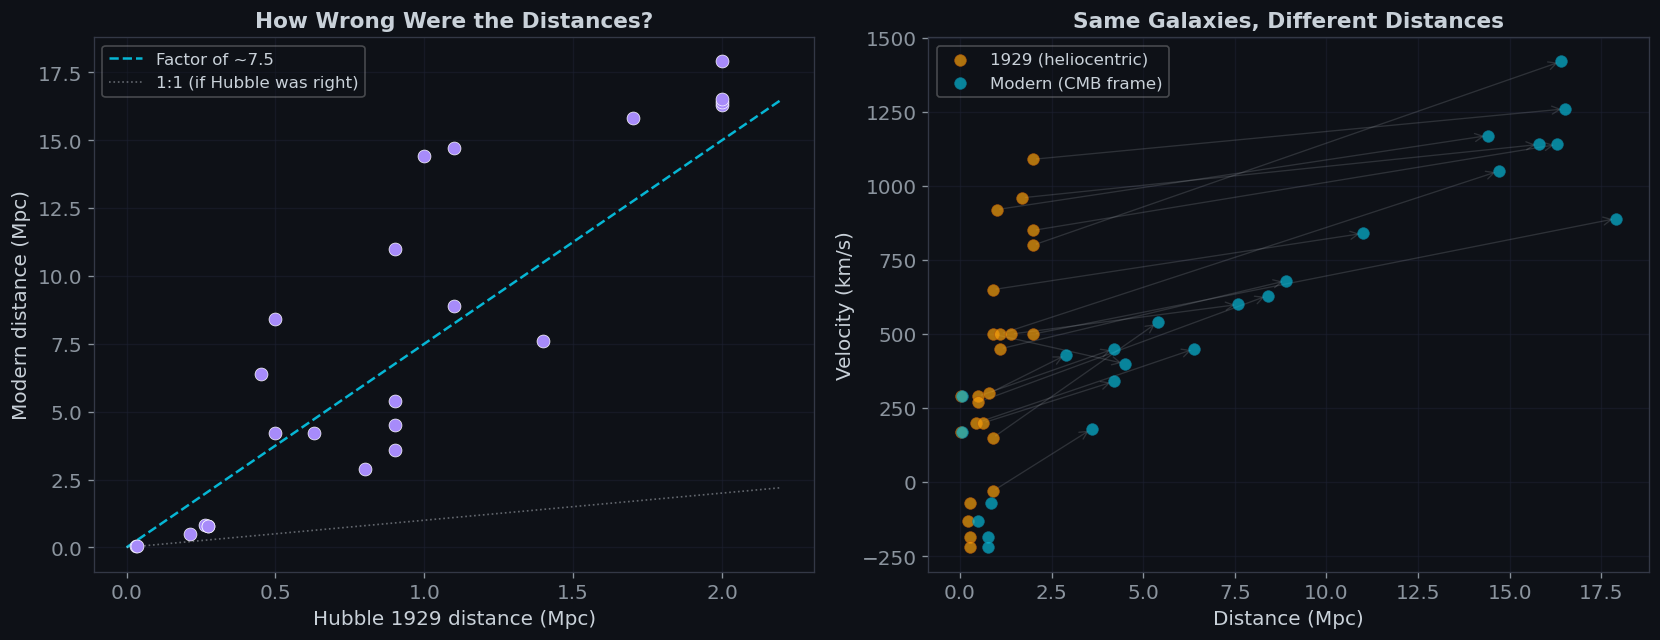

The arrows show each galaxy moving to its corrected position
(rightward = larger distance, upward = CMB velocity correction).
The slope (H₀) drops dramatically!


In [15]:
# ── Compare the two distance scales ────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: 1929 vs modern distances
ax1.scatter(d_1929, d_modern, c=PURPLE, s=60, zorder=5,
            edgecolors='white', linewidths=0.4)
d_range = np.linspace(0, 2.2, 100)
ax1.plot(d_range, 7.5 * d_range, color=CYAN, ls='--', lw=1.5,
         label='Factor of ~7.5')
ax1.plot(d_range, d_range, color=WHITE, ls=':', lw=1, alpha=0.4,
         label='1:1 (if Hubble was right)')
ax1.set_xlabel('Hubble 1929 distance (Mpc)', fontsize=12)
ax1.set_ylabel('Modern distance (Mpc)', fontsize=12)
ax1.set_title('How Wrong Were the Distances?', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, framealpha=0.3)

# Right: Both Hubble diagrams
ax2.scatter(d_1929, v_obs, c=AMBER, s=50, zorder=5, alpha=0.7,
            edgecolors='#b45309', linewidths=0.4, label='1929 (heliocentric)')
ax2.scatter(d_modern, v_cmb, c=CYAN, s=50, zorder=5, alpha=0.7,
            edgecolors='#0e7490', linewidths=0.4, label='Modern (CMB frame)')

# Arrows connecting same galaxies
for i in range(len(d_1929)):
    if d_1929[i] > 0.4:  # skip very nearby ones for clarity
        ax2.annotate('', xy=(d_modern[i], v_cmb[i]),
                     xytext=(d_1929[i], v_obs[i]),
                     arrowprops=dict(arrowstyle='->', color=WHITE, alpha=0.15, lw=0.8))

ax2.set_xlabel('Distance (Mpc)', fontsize=12)
ax2.set_ylabel('Velocity (km/s)', fontsize=12)
ax2.set_title('Same Galaxies, Different Distances', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, framealpha=0.3)

plt.tight_layout()
plt.show()

print('The arrows show each galaxy moving to its corrected position')
print('(rightward = larger distance, upward = CMB velocity correction).')
print('The slope (H₀) drops dramatically!')

---
### Run MCMC on Modern Data

Two corrections are needed:

1. **Exclude Local Group galaxies** (d < 1 Mpc) — peculiar velocities dominate at close range
2. **Use CMB-frame velocities** — Hubble's raw velocities are heliocentric, but we need to subtract our own motion through the universe. The Sun moves at ~370 km/s relative to the CMB, which adds ~150–350 km/s to recession velocities depending on the galaxy's direction.

In [16]:
# ── Exclude Local Group galaxies (d < 1 Mpc) ──────────
mask = d_modern > 1.0
d_fit_modern = d_modern[mask]
v_fit_modern = v_cmb[mask]   # CMB-frame velocities!
names_fit    = [n for n, m in zip(names, mask) if m]

print(f'Fitting {mask.sum()} galaxies with d > 1 Mpc (excluding Local Group)')
print(f'Excluded: {[n for n, m in zip(names, mask) if not m]}')
print(f'Using CMB-frame velocities (corrected for our local motion)')

# ── Build posterior for modern data ────────────────────
lp_mod, glp_mod = make_posterior(d_fit_modern, v_fit_modern,
                                  sigma_v=250.0, H0_max=200.0)

# ── Run both samplers ─────────────────────────────────
mh_chain_mod, mh_acc_mod = metropolis_hastings(
    lp_mod, start=50.0, n_steps=25000, step_size=2.0)
mh_samples_mod = mh_chain_mod[burn:]

hmc_chain_mod, hmc_acc_mod = hmc_sampler(
    lp_mod, glp_mod, start=50.0, n_steps=8000, eps=0.06, L=20)
hmc_samples_mod = hmc_chain_mod[500:]

print(f'\n═══ MODERN DATA ═══')
print(f'  MH:  H₀ = {np.mean(mh_samples_mod):.1f} ± {np.std(mh_samples_mod):.1f} km/s/Mpc  (accept: {mh_acc_mod:.0%})')
print(f'  HMC: H₀ = {np.mean(hmc_samples_mod):.1f} ± {np.std(hmc_samples_mod):.1f} km/s/Mpc  (accept: {hmc_acc_mod:.0%})')
print(f'\n  Literature value: ~70 km/s/Mpc')

Fitting 18 galaxies with d > 1 Mpc (excluding Local Group)
Excluded: ['SMC', 'LMC', 'NGC 6822', 'NGC 598', 'NGC 221', 'NGC 224']
Using CMB-frame velocities (corrected for our local motion)

═══ MODERN DATA ═══
  MH:  H₀ = 73.6 ± 5.3 km/s/Mpc  (accept: 88%)
  HMC: H₀ = 74.0 ± 5.0 km/s/Mpc  (accept: 100%)

  Literature value: ~70 km/s/Mpc


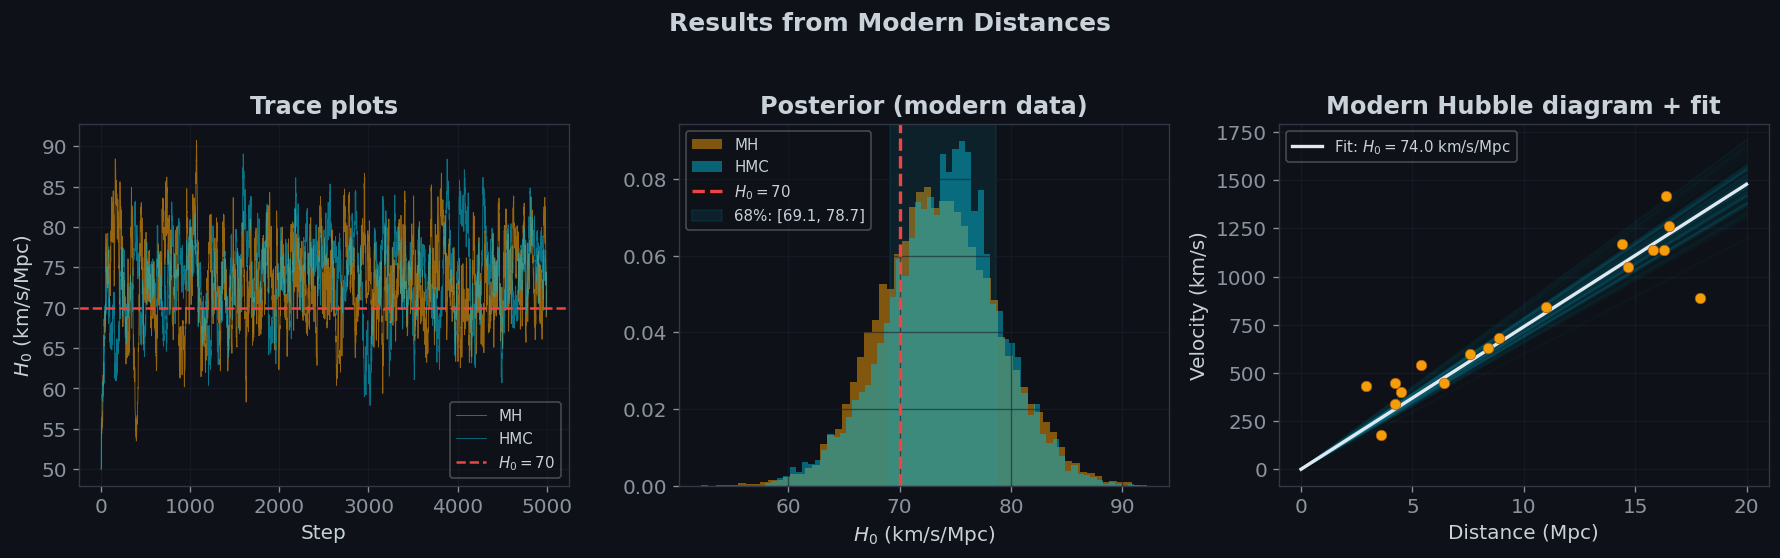

In [17]:
# ── Visualise modern results ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Trace
axes[0].plot(mh_chain_mod[:5000], color=AMBER, alpha=0.6, lw=0.5, label='MH')
axes[0].plot(hmc_chain_mod[:5000], color=CYAN, alpha=0.6, lw=0.5, label='HMC')
axes[0].axhline(70, color=RED, ls='--', lw=1.5, label='$H_0 = 70$')
axes[0].set_ylabel('$H_0$ (km/s/Mpc)')
axes[0].set_xlabel('Step')
axes[0].set_title('Trace plots', fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.3)

# Histogram
axes[1].hist(mh_samples_mod, bins=60, density=True, alpha=0.5,
             color=AMBER, edgecolor='none', label='MH')
axes[1].hist(hmc_samples_mod, bins=60, density=True, alpha=0.5,
             color=CYAN, edgecolor='none', label='HMC')
axes[1].axvline(70, color=RED, ls='--', lw=2, label='$H_0 = 70$')
lo, hi = np.percentile(hmc_samples_mod, [16, 84])
axes[1].axvspan(lo, hi, alpha=0.1, color=CYAN,
                label=f'68%: [{lo:.1f}, {hi:.1f}]')
axes[1].set_xlabel('$H_0$ (km/s/Mpc)')
axes[1].set_title('Posterior (modern data)', fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.3)

# Fit on data
d_plot = np.linspace(0, 20, 100)
for k in np.random.choice(len(hmc_samples_mod), 100, replace=False):
    axes[2].plot(d_plot, hmc_samples_mod[k] * d_plot, color=CYAN, alpha=0.03)
axes[2].scatter(d_fit_modern, v_fit_modern, c=AMBER, s=40, zorder=5,
                edgecolors='#b45309', linewidths=0.4)
H_mod = np.mean(hmc_samples_mod)
axes[2].plot(d_plot, H_mod * d_plot, color=WHITE, lw=2,
             label=f'Fit: $H_0 = {H_mod:.1f}$ km/s/Mpc')
axes[2].set_xlabel('Distance (Mpc)')
axes[2].set_ylabel('Velocity (km/s)')
axes[2].set_title('Modern Hubble diagram + fit', fontweight='bold')
axes[2].legend(fontsize=9, framealpha=0.3)

fig.suptitle('Results from Modern Distances', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## Part 3: The Full Comparison

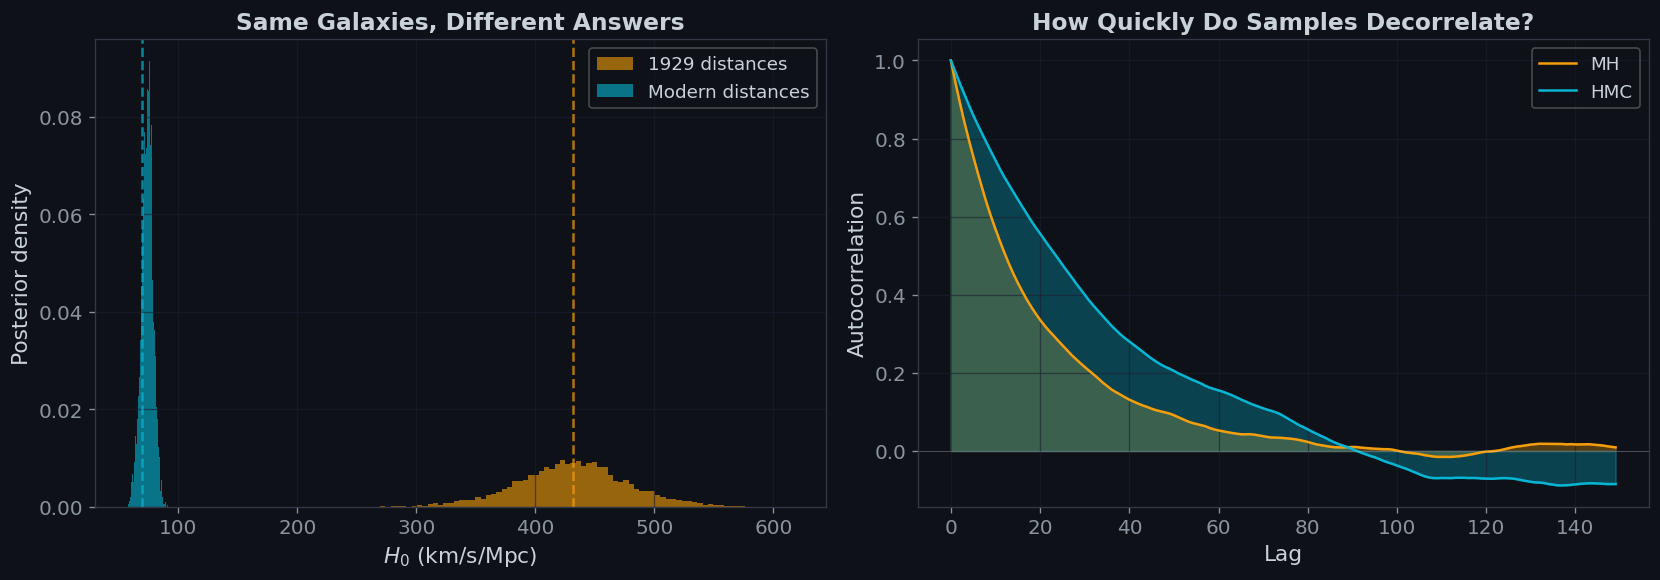

In [18]:
# ── Side-by-side posteriors ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Both posteriors
ax1.hist(hmc_samples_29, bins=80, density=True, alpha=0.6,
         color=AMBER, edgecolor='none', label='1929 distances')
ax1.hist(hmc_samples_mod, bins=80, density=True, alpha=0.6,
         color=CYAN, edgecolor='none', label='Modern distances')
ax1.axvline(np.mean(hmc_samples_29), color=AMBER, ls='--', lw=1.5, alpha=0.7)
ax1.axvline(70, color=CYAN, ls='--', lw=1.5, alpha=0.7)
ax1.set_xlabel('$H_0$ (km/s/Mpc)', fontsize=13)
ax1.set_ylabel('Posterior density', fontsize=13)
ax1.set_title('Same Galaxies, Different Answers', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, framealpha=0.3)

# Right: Autocorrelation comparison (modern data, MH vs HMC)
lags = np.arange(150)
mh_acf  = autocorr(mh_samples_mod)
hmc_acf = autocorr(hmc_samples_mod)

ax2.fill_between(lags, 0, mh_acf, alpha=0.3, color=AMBER)
ax2.plot(lags, mh_acf, color=AMBER, lw=1.5, label='MH')
ax2.fill_between(lags, 0, hmc_acf, alpha=0.3, color=CYAN)
ax2.plot(lags, hmc_acf, color=CYAN, lw=1.5, label='HMC')
ax2.axhline(0, color=WHITE, lw=0.5, alpha=0.3)
ax2.set_xlabel('Lag', fontsize=13)
ax2.set_ylabel('Autocorrelation', fontsize=13)
ax2.set_title('How Quickly Do Samples Decorrelate?', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11, framealpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# ── Final summary ──────────────────────────────────────
H29  = np.mean(hmc_samples_29)
eH29 = np.std(hmc_samples_29)
Hmod = np.mean(hmc_samples_mod)
eHmod= np.std(hmc_samples_mod)
lo29, hi29 = np.percentile(hmc_samples_29, [16, 84])
loM, hiM   = np.percentile(hmc_samples_mod, [16, 84])

print('┌────────────────────────────────────────────────────────────────┐')
print('│            HUBBLE CONSTANT — THEN AND NOW                     │')
print('├────────────────────────────────────────────────────────────────┤')
print(f'│  Hubble 1929 data:                                            │')
print(f'│    H₀ = {H29:.0f} ± {eH29:.0f} km/s/Mpc                              │')
print(f'│    68% CI: [{lo29:.0f}, {hi29:.0f}]                                    │')
print(f'│                                                                │')
print(f'│  Modern distances:                                             │')
print(f'│    H₀ = {Hmod:.1f} ± {eHmod:.1f} km/s/Mpc                              │')
print(f'│    68% CI: [{loM:.1f}, {hiM:.1f}]                                    │')
print(f'│                                                                │')
print(f'│  Correction factor: {H29/Hmod:.1f}x  (≈ ratio of distance scales)     │')
print(f'│  Current literature value: ~70 km/s/Mpc                        │')
print('└────────────────────────────────────────────────────────────────┘')

┌────────────────────────────────────────────────────────────────┐
│            HUBBLE CONSTANT — THEN AND NOW                     │
├────────────────────────────────────────────────────────────────┤
│  Hubble 1929 data:                                            │
│    H₀ = 431 ± 46 km/s/Mpc                              │
│    68% CI: [387, 476]                                    │
│                                                                │
│  Modern distances:                                             │
│    H₀ = 74.0 ± 5.0 km/s/Mpc                              │
│    68% CI: [69.1, 78.7]                                    │
│                                                                │
│  Correction factor: 5.8x  (≈ ratio of distance scales)     │
│  Current literature value: ~70 km/s/Mpc                        │
└────────────────────────────────────────────────────────────────┘


---
## What Did We Learn?

### About the Universe
- Hubble's 1929 data **really did** show the expansion of the universe — the velocity-distance correlation was genuine
- But his distance calibration was off by a factor of ~6–7, which made $H_0$ too large and the implied age of the universe embarrassingly short ($t \sim 1/H_0 \sim 2$ billion years — younger than the Earth!)
- Modern distance techniques (Cepheid recalibration, TRGB, masers, SNe Ia) brought $H_0$ down to ~70 km/s/Mpc

### About MCMC
- Both MH and HMC converge to the same posterior — they're just different ways to sample it
- HMC converges faster and produces less correlated samples
- The posterior correctly captures our **uncertainty** — it's not just a best-fit number, it's a full probability distribution
- Systematic errors in the data (wrong distances) don't show up in the posterior width — **MCMC can't fix bad data!**

### Exercises
1. **Include the Local Group galaxies** in the modern fit. What happens to $H_0$ and why?
2. **Increase $\sigma_v$** to 500 km/s. How does the posterior width change?
3. **Use a tighter prior**, e.g. $H_0 \sim \mathcal{N}(70, 10^2)$. Does it change the modern result much? What about the 1929 result?
4. **The Hubble tension**: the CMB gives $H_0 \approx 67.4$, while local measurements give $\approx 73$. Our error bars are too wide to see this — what would you need to improve?

---
*Data: Hubble (1929), PNAS 15(3), 168–173. Modern distances from NED and the HST Key Project.*